# 03 - Wave Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_{tt} = c^2 u_{xx}$, $c = 1.0$

**IC:** $u(x,0) = \sin(\pi x)$, $u_t(x,0) = 0$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

**Note:** Wave equation is second-order in time - requires velocity IC.
Oscillatory nature makes it sensitive to sparse data.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    WaveFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'wave'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'c': 1.0}
RESULTS    = '../results/wave/'
FIGURES    = '../figures/wave/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, c=1.0)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

WaveFDM solved in 0.0220s


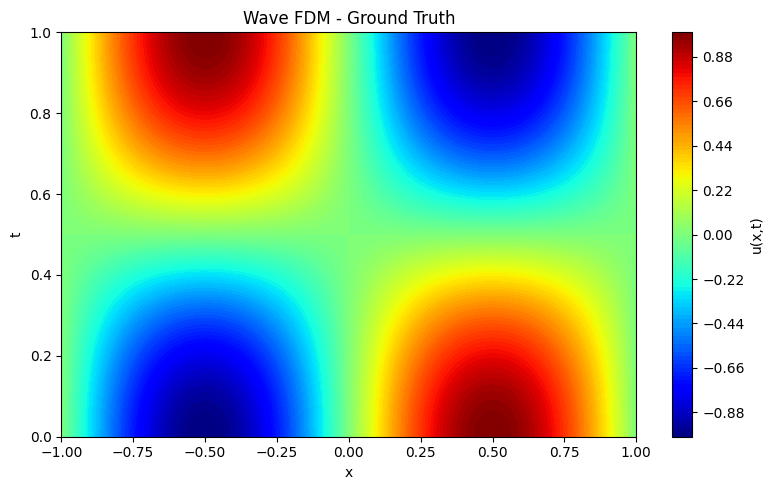

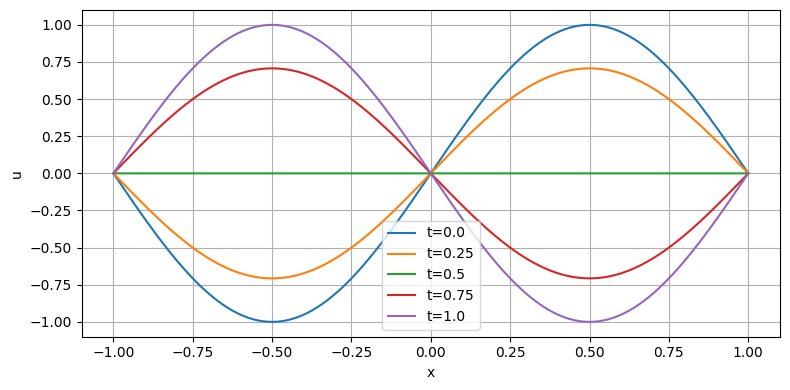

In [2]:
fdm = WaveFDM(nx=256, nt=2000, c=1.0)
fdm.solve()
fdm.plot_solution(title='Wave FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')
print(f'Wave data includes u_ic_dt: {"u_ic_dt" in data_clean_dense}')

Data ready
Wave data includes u_ic_dt: True


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Wave | Vanilla Clean | Epoch     0/10000] Total: 0.568947 | IC: 0.424515 | BC: 0.080786 | PDE: 0.012729


[Wave | Vanilla Clean | Epoch  1000/10000] Total: 0.035608 | IC: 0.013693 | BC: 0.021078 | PDE: 0.000168


[Wave | Vanilla Clean | Epoch  2000/10000] Total: 0.009932 | IC: 0.003545 | BC: 0.005862 | PDE: 0.000105


[Wave | Vanilla Clean | Epoch  3000/10000] Total: 0.002088 | IC: 0.000819 | BC: 0.000969 | PDE: 0.000060


...

[Wave | Vanilla Clean | Epoch  6000/10000] Total: 0.000432 | IC: 0.000177 | BC: 0.000082 | PDE: 0.000035


[Wave | Vanilla Clean | Epoch  7000/10000] Total: 0.000293 | IC: 0.000127 | BC: 0.000078 | PDE: 0.000017


[Wave | Vanilla Clean | Epoch  8000/10000] Total: 0.001065 | IC: 0.000194 | BC: 0.000213 | PDE: 0.000132


[Wave | Vanilla Clean | Epoch  9000/10000] Total: 0.000652 | IC: 0.000110 | BC: 0.000089 | PDE: 0.000091



Training complete in 206.48s


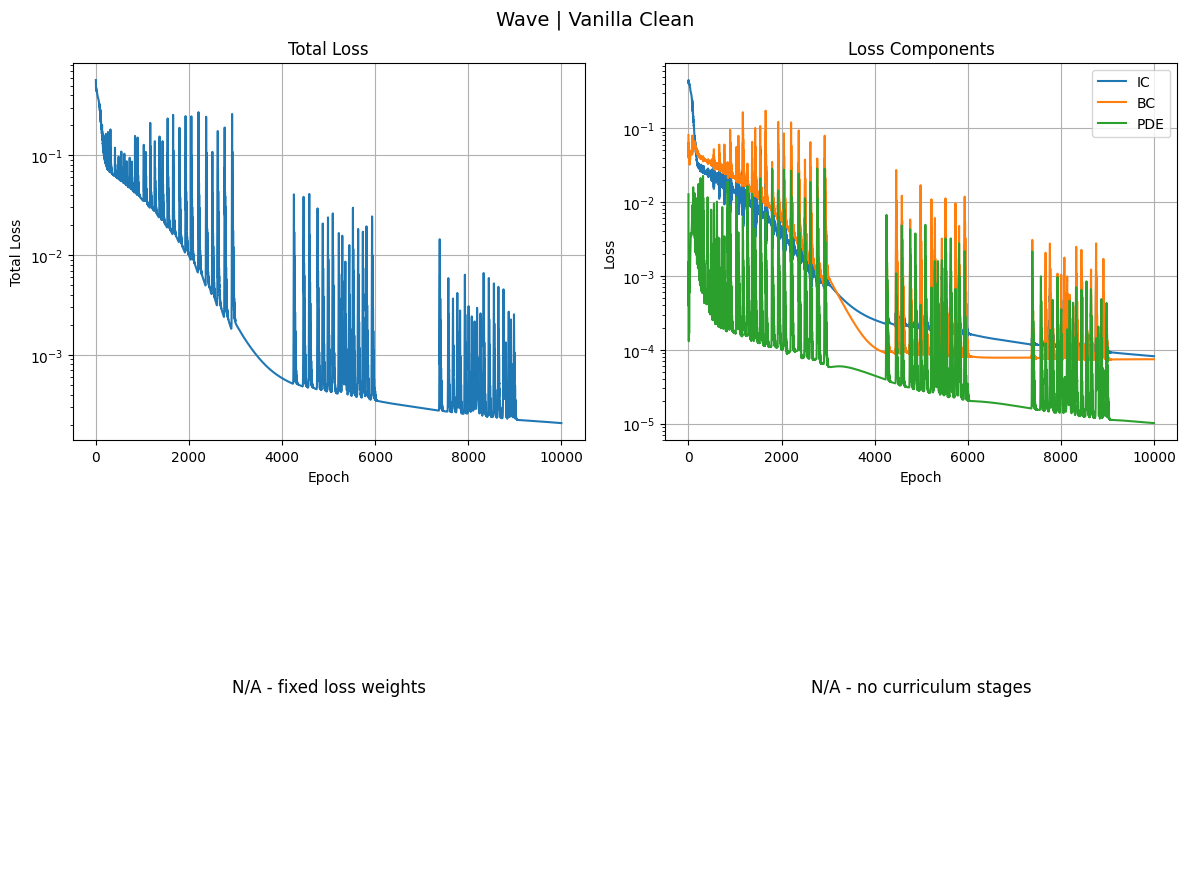

Saved: ../figures/wave/vanilla_clean_training.png
Saved: ../figures/wave/vanilla_clean_training.csv


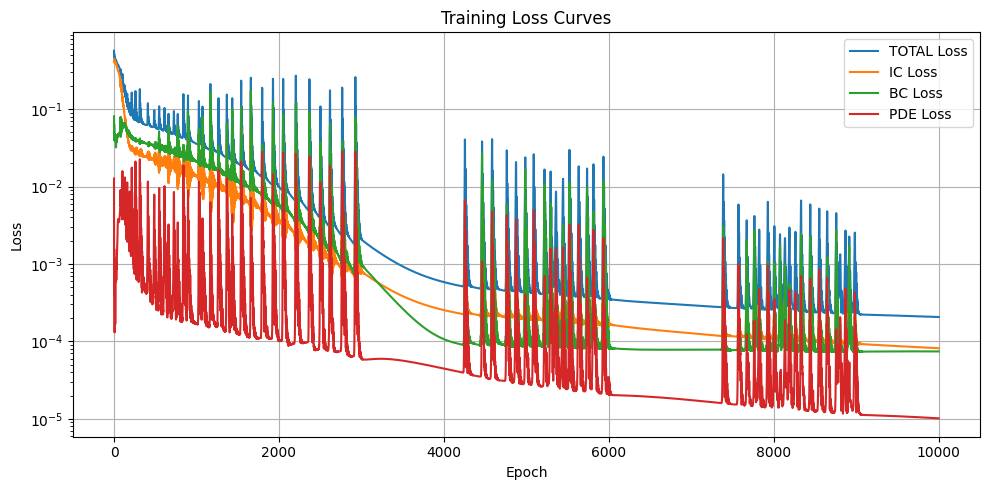

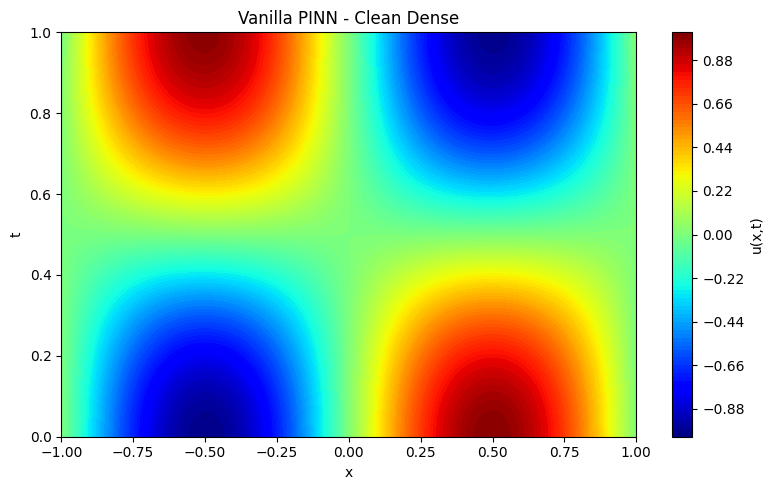

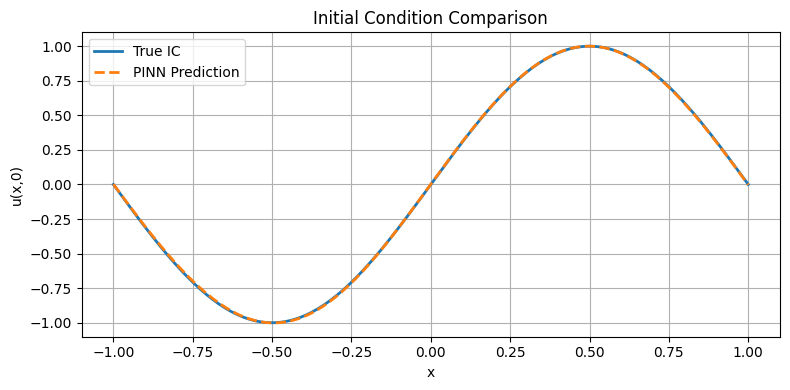

Saved: ../results/wave/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Wave | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Wave | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

[Wave | Vanilla Noisy | Epoch     0/10000] Total: 0.554008 | IC: 0.429647 | BC: 0.088830 | PDE: 0.007106


[Wave | Vanilla Noisy | Epoch  1000/10000] Total: 0.066408 | IC: 0.034214 | BC: 0.030699 | PDE: 0.000299


[Wave | Vanilla Noisy | Epoch  2000/10000] Total: 0.038723 | IC: 0.017328 | BC: 0.019543 | PDE: 0.000370


[Wave | Vanilla Noisy | Epoch  3000/10000] Total: 0.031930 | IC: 0.010689 | BC: 0.014857 | PDE: 0.001277


[Wave | Vanilla Noisy | Epoch  4000/10000] Total: 0.023316 | IC: 0.008770 | BC: 0.013782 | PDE: 0.000153


...

[Wave | Vanilla Noisy | Epoch  6000/10000] Total: 0.021739 | IC: 0.006854 | BC: 0.013766 | PDE: 0.000224


[Wave | Vanilla Noisy | Epoch  7000/10000] Total: 0.020436 | IC: 0.006374 | BC: 0.013706 | PDE: 0.000071


[Wave | Vanilla Noisy | Epoch  8000/10000] Total: 0.020177 | IC: 0.006236 | BC: 0.013683 | PDE: 0.000052


[Wave | Vanilla Noisy | Epoch  9000/10000] Total: 0.020101 | IC: 0.006205 | BC: 0.013644 | PDE: 0.000050



Training complete in 182.42s


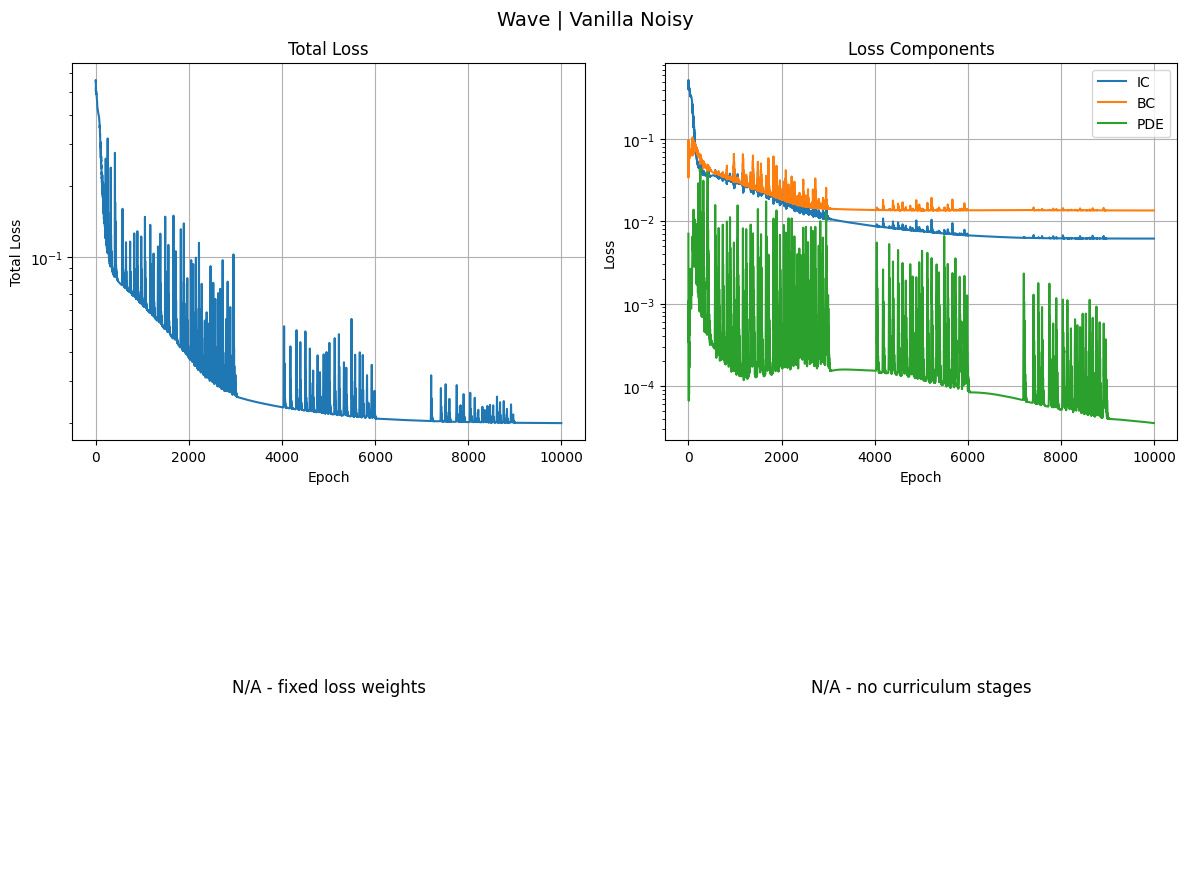

Saved: ../figures/wave/vanilla_noisy_training.png
Saved: ../figures/wave/vanilla_noisy_training.csv


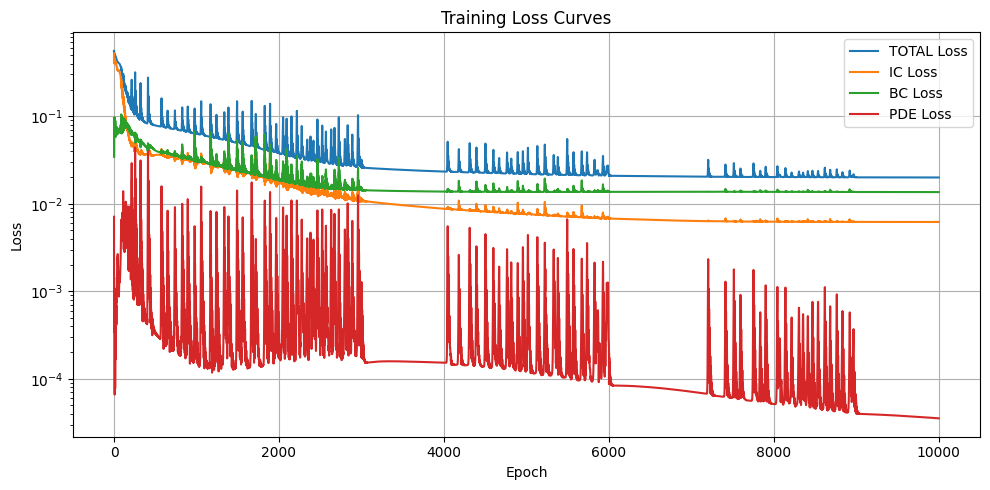

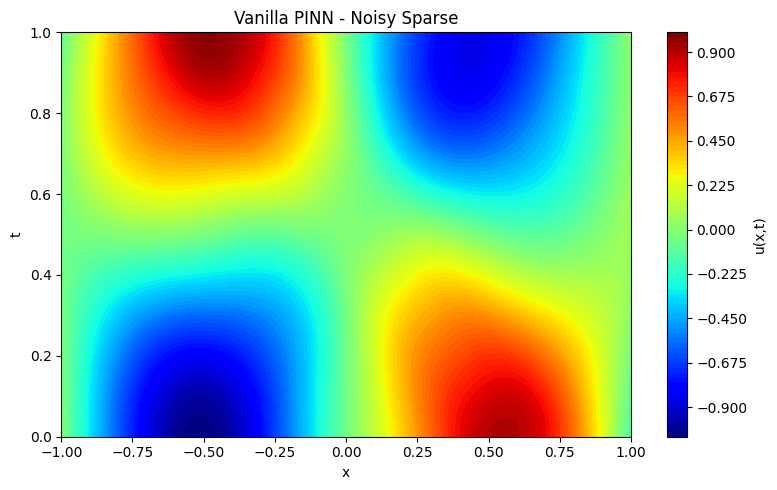

Saved: ../results/wave/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Wave | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Wave | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Wave | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 1.094772 | IC: 0.805165 | BC: 0.241256 | PDE: 0.009670 | lam=(1.00,1.00,5.00)


[Wave | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.173244 | IC: 0.033484 | BC: 0.027976 | PDE: 0.004242 | lam=(1.83,2.49,10.00)


[Wave | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.085699 | IC: 0.012478 | BC: 0.013116 | PDE: 0.002939 | lam=(2.29,2.12,10.00)


[Wave | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.052795 | IC: 0.011477 | BC: 0.013309 | PDE: 0.000284 | lam=(1.95,2.07,10.00)


[Wave | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.006364 | IC: 0.001316 | BC: 0.001307 | PDE: 0.000105 | lam=(1.99,2.06,10.00)


...

[Wave | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000247 | IC: 0.000105 | BC: 0.000060 | PDE: 0.000066 | lam=(1.36,0.78,0.86)


[Wave | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000212 | IC: 0.000090 | BC: 0.000054 | PDE: 0.000054 | lam=(1.37,0.81,0.82)


[Wave | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.000380 | IC: 0.000104 | BC: 0.000056 | PDE: 0.000165 | lam=(0.96,0.52,1.52)


[Wave | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.000280 | IC: 0.000093 | BC: 0.000053 | PDE: 0.000113 | lam=(1.08,0.62,1.30)



AC-PINN training complete in 219.68s


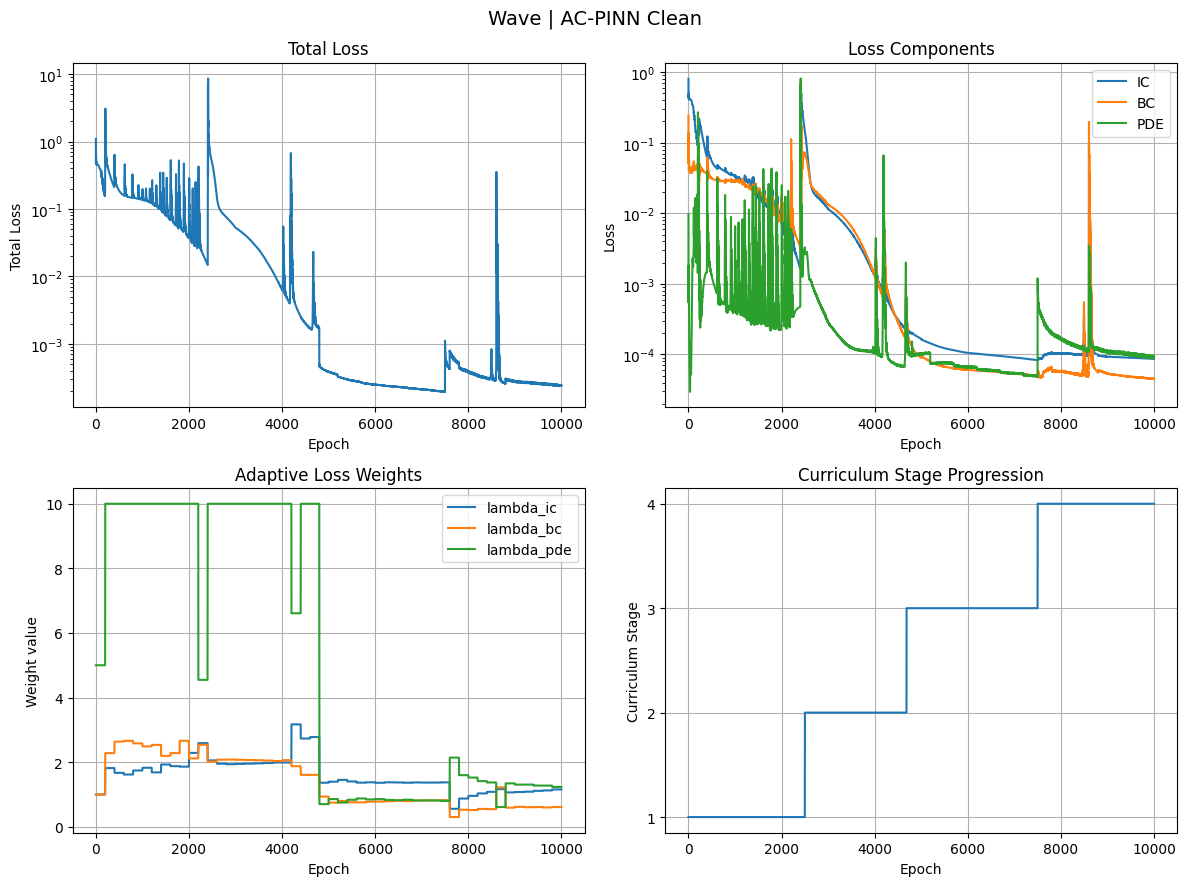

Saved: ../figures/wave/acpinn_clean_training.png
Saved: ../figures/wave/acpinn_clean_training.csv


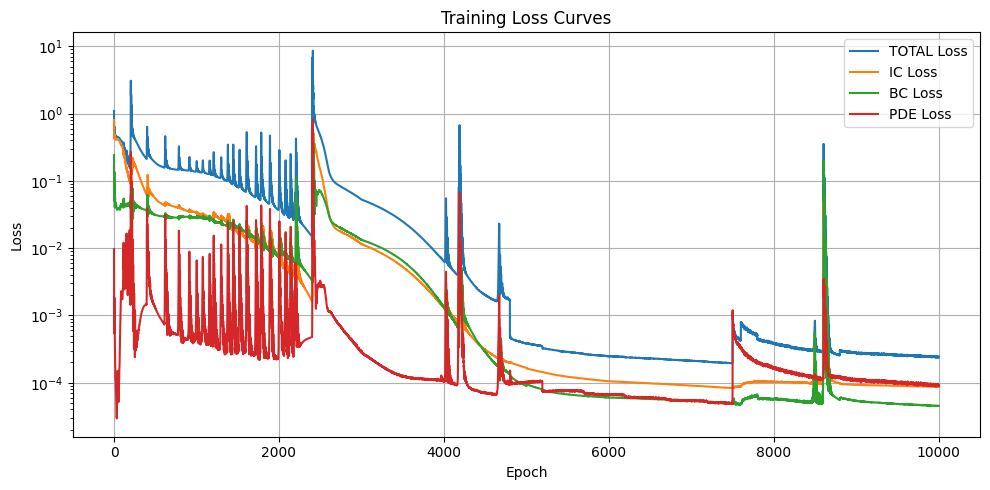

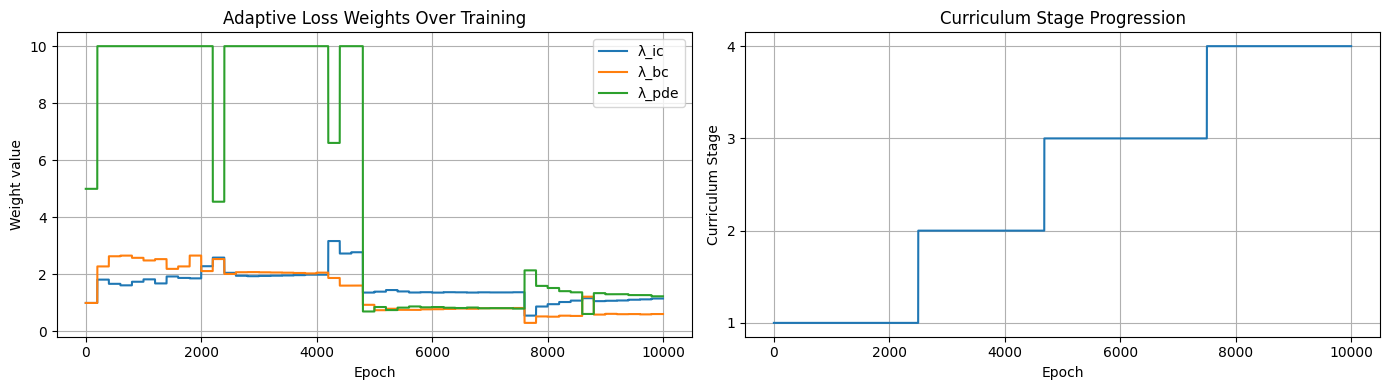

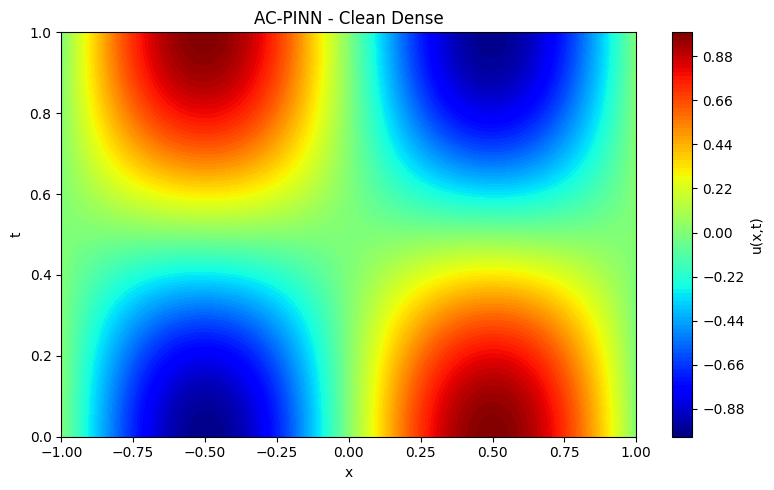

Saved: ../results/wave/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Wave | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Wave | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

[Wave | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.767453 | IC: 0.696153 | BC: 0.068724 | PDE: 0.000515 | lam=(1.00,1.00,5.00)


[Wave | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.124913 | IC: 0.029141 | BC: 0.027251 | PDE: 0.001017 | lam=(2.14,1.92,10.00)


[Wave | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.092785 | IC: 0.023375 | BC: 0.019193 | PDE: 0.000408 | lam=(1.66,2.60,10.00)


[Wave | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.089894 | IC: 0.020040 | BC: 0.022420 | PDE: 0.000415 | lam=(2.16,1.89,10.00)


[Wave | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.075518 | IC: 0.016662 | BC: 0.018428 | PDE: 0.000389 | lam=(2.13,1.96,10.00)


...

[Wave | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.038308 | IC: 0.012564 | BC: 0.014981 | PDE: 0.003188 | lam=(1.23,1.46,0.31)


[Wave | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.036698 | IC: 0.011596 | BC: 0.014528 | PDE: 0.002734 | lam=(1.21,1.51,0.28)


[Wave | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.042962 | IC: 0.016560 | BC: 0.014932 | PDE: 0.004911 | lam=(1.36,1.23,0.40)


[Wave | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.037179 | IC: 0.012411 | BC: 0.014383 | PDE: 0.003107 | lam=(1.25,1.44,0.31)



AC-PINN training complete in 196.35s


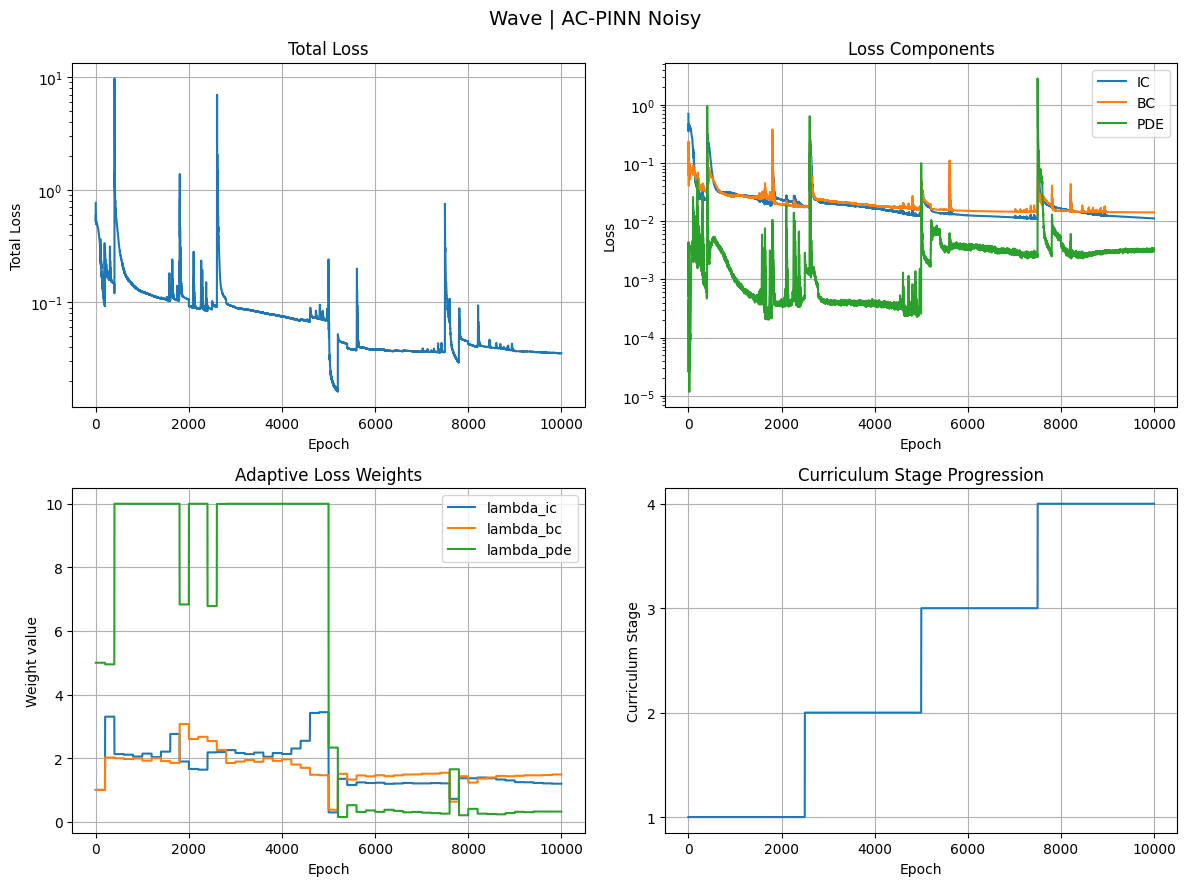

Saved: ../figures/wave/acpinn_noisy_training.png
Saved: ../figures/wave/acpinn_noisy_training.csv


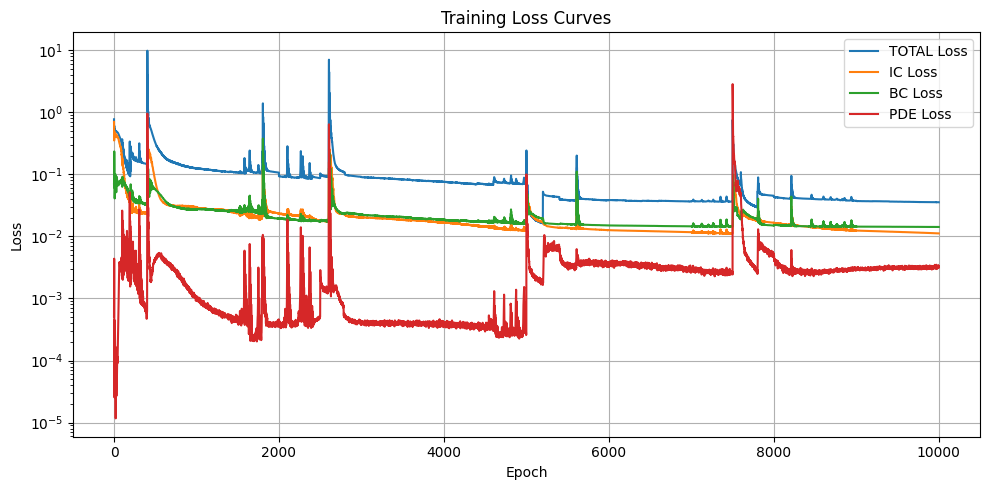

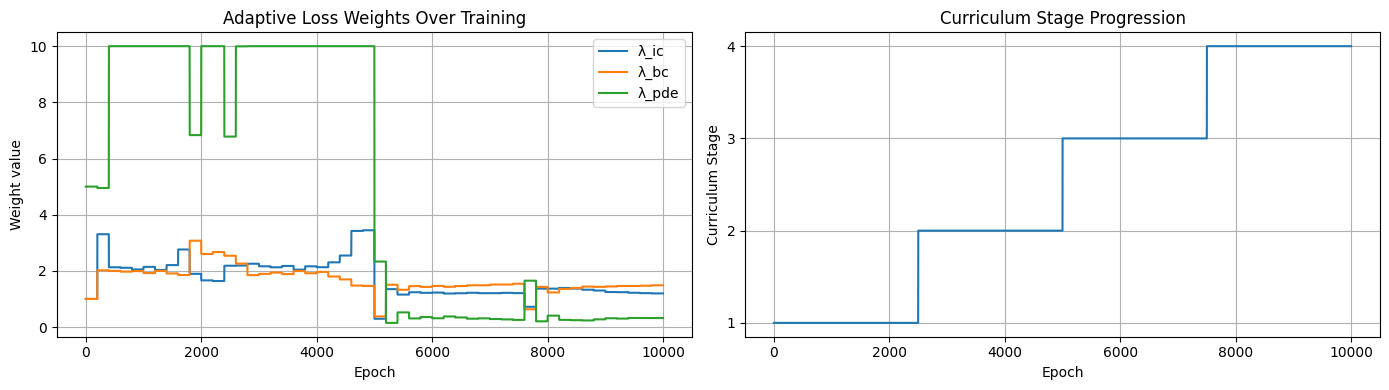

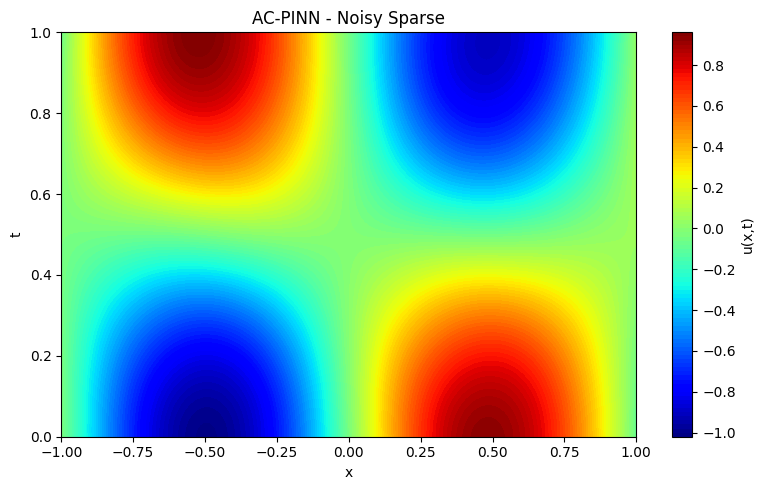

Saved: ../results/wave/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Wave | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Wave | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.017405   0.023984   0.006899   0.008680
  Vanilla (noisy)             0.145252   0.225846   0.054455   0.072440
  AC-PINN (clean)             0.018482   0.025745   0.007242   0.009217
  AC-PINN (noisy)             0.088504   0.097683   0.037443   0.044138


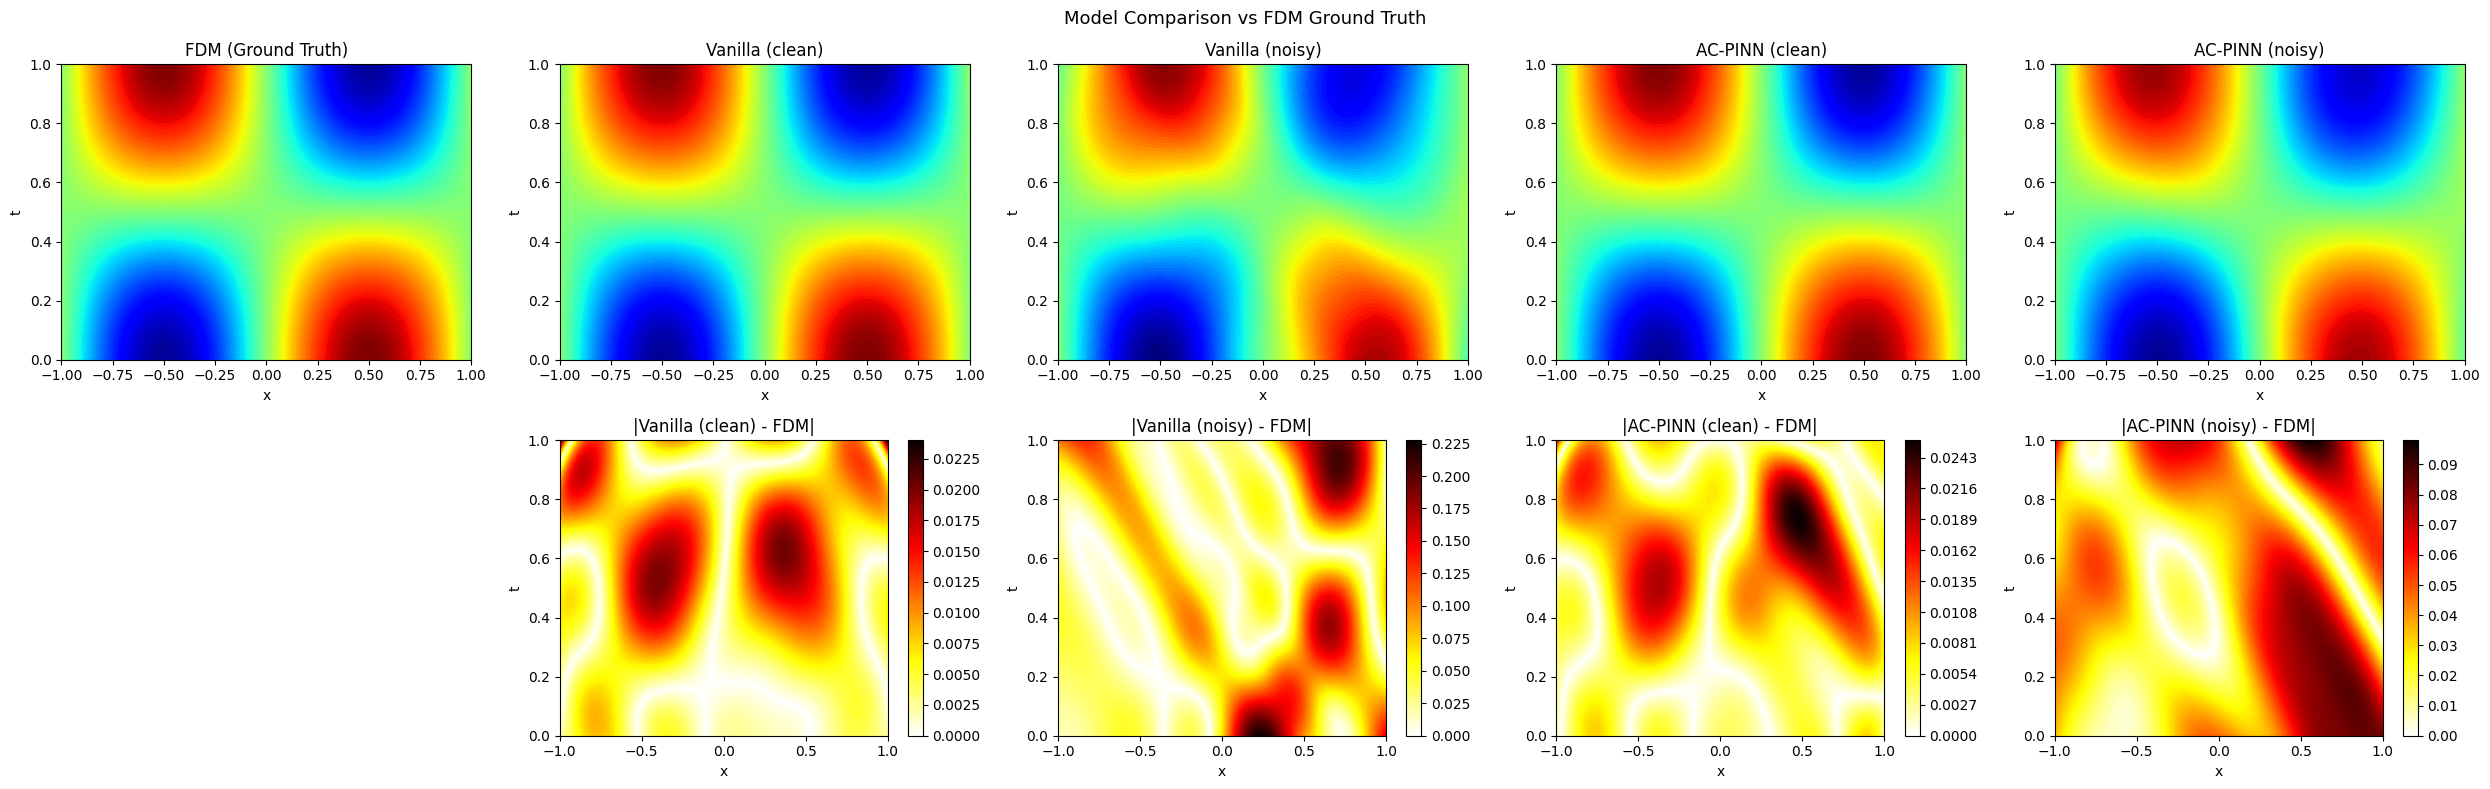

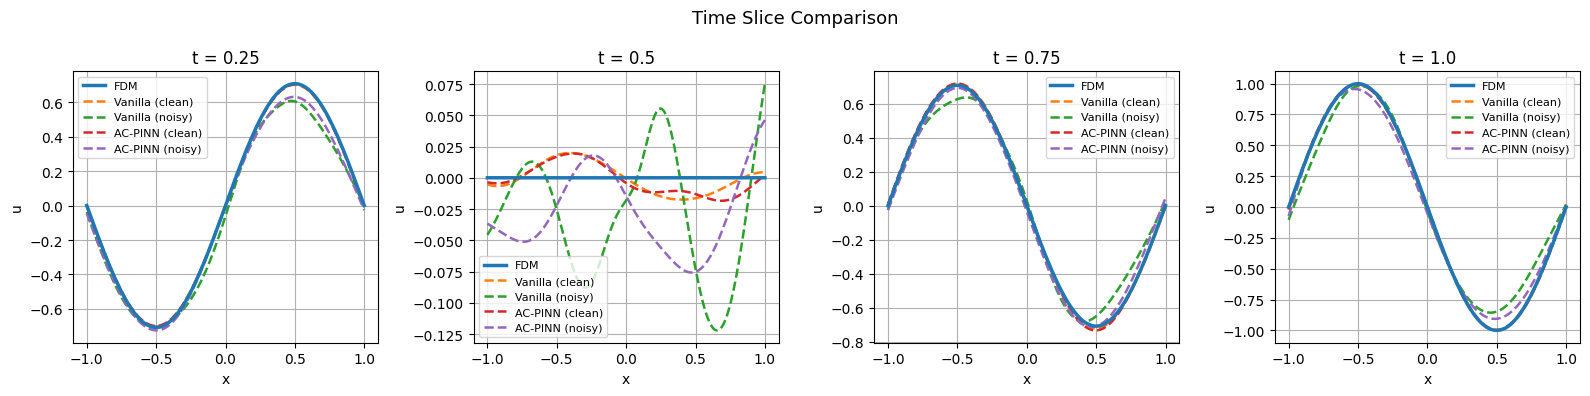

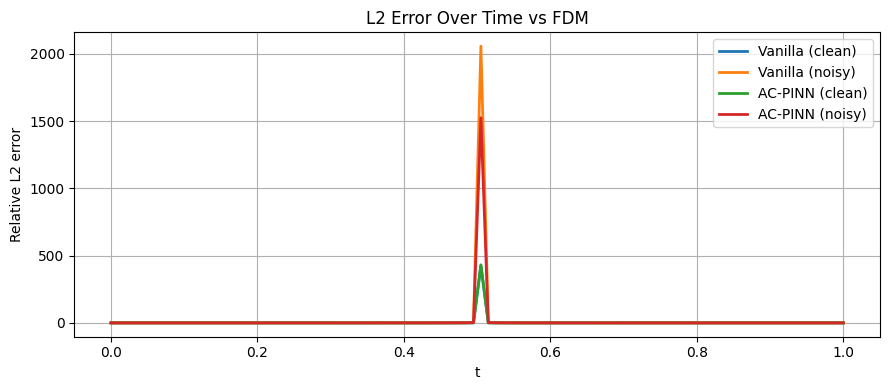

Saved: ../results/wave/benchmark_metrics.npy
Wave experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Wave experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.617425 | IC: 0.541821 | BC: 0.052306 | PDE: 0.004660


[Epoch  2500/5000] Total: 0.018774 | IC: 0.007420 | BC: 0.010527 | PDE: 0.000165



Training complete in 92.39s
[Epoch     0/5000] Stage 1/4 | Total: 0.674410 | IC: 0.351918 | BC: 0.306944 | PDE: 0.003110 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.615779 | IC: 0.023408 | BC: 0.010660 | PDE: 0.051940 | lam=(1.24,6.33,10.00)



AC-PINN training complete in 98.68s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.045641   0.077665   0.018773   0.022762
  AC-PINN ε=0.05              0.264717   0.424649   0.107848   0.132019

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.873709 | IC: 0.734249 | BC: 0.074764 | PDE: 0.012939


...


AC-PINN training complete in 98.30s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.063348   0.073341   0.026154   0.031593
  AC-PINN ε=0.1               0.079947   0.177896   0.031791   0.039871

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.737971 | IC: 0.627286 | BC: 0.102957 | PDE: 0.001546


[Epoch  2500/5000] Total: 0.138616 | IC: 0.081022 | BC: 0.056785 | PDE: 0.000162



Training complete in 92.27s
[Epoch     0/5000] Stage 1/4 | Total: 0.642991 | IC: 0.566646 | BC: 0.076261 | PDE: 0.000017 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 3.163631 | IC: 0.091038 | BC: 0.051895 | PDE: 0.282110 | lam=(1.40,4.14,10.00)



AC-PINN training complete in 98.58s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.254732   0.285319   0.104504   0.127039
  AC-PINN ε=0.2               0.278913   0.510271   0.115600   0.139099
Saved: ../results/wave/noise_study_metrics.npy
